# 🚗 Waze Kullanıcı Terk Etme (Churn) Tahmini Projesi

## Makine Öğrenmesi Final Projesi

**Proje Konusu:** Customer Churn Prediction (Müşteri Terk Etme Tahmini)  
**Kullanılan Algoritmalar:** Logistic Regression & XGBoost  
**Veri Seti:** Waze Navigasyon Uygulaması Kullanıcı Verileri  
**Tarih:** 2025

---

# 1. Problem Tanımı

## 1.1 Proje Amacı

Bu projede, **Waze navigasyon uygulamasının kullanıcı verilerini** kullanarak bir müşterinin uygulamayı **terk edip etmeyeceğini (churn)** tahmin etmeyi amaçlıyoruz.

## 1.2 Veri Seti Hangi Problemi Temsil Ediyor?

Veri seti, Waze navigasyon uygulamasını kullanan **14.999 kullanıcıya** ait davranışsal verileri içermektedir. Bu veriler; kullanıcıların oturum sayıları, sürüş bilgileri, favori navigasyon kullanımları, uygulama aktivite günleri ve cihaz türü gibi bilgileri kapsar. Problem, bu davranışsal örüntülerden yola çıkarak bir kullanıcının uygulamayı bırakıp bırakmayacağını tahmin etmektir.

## 1.3 Tahmin Edilmek İstenen Değişken

Hedef değişken **`label`** sütunudur:
- **`retained`** → Kullanıcı uygulamayı kullanmaya devam ediyor (0)
- **`churned`** → Kullanıcı uygulamayı terk etmiş (1)

## 1.4 Problem Türü

Bu problem bir **İkili Sınıflandırma (Binary Classification)** problemidir. Hedef değişken yalnızca iki kategoriden oluşmaktadır: "retained" ve "churned".

## 1.5 Başarı Nasıl Ölçülecek?

Model başarısı aşağıdaki metriklerle değerlendirilecektir:

| Metrik | Açıklama |
|--------|----------|
| **Accuracy** | Genel doğruluk oranı |
| **Precision** | Pozitif tahminlerin doğruluğu |
| **Recall (Sensitivity)** | Gerçek pozitiflerin yakalanma oranı |
| **F1-Score** | Precision ve Recall'un harmonik ortalaması |
| **ROC-AUC** | Sınıflandırıcının ayırt edicilik gücü |
| **Confusion Matrix** | Tahminlerin detaylı dağılımı |

Churn tahmini senaryosunda **Recall** metriği özellikle önemlidir, çünkü terk etme eğilimindeki müşterilerin kaçırılması işletme açısından büyük kayıplara yol açabilir.

---
# 2. Veri Seti Analizi (Exploratory Data Analysis - EDA)

## 2.1 Gerekli Kütüphanelerin Yüklenmesi ve Çıktı Klasörünün Oluşturulması

Proje boyunca üretilecek tüm grafikler ve sonuç dosyaları `outputs/` isimli bir klasöre otomatik olarak kaydedilecektir.

In [34]:
# Temel kütüphaneler
import os
import pandas as pd
import numpy as np

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Ön işleme kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model kütüphaneleri
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Değerlendirme metrikleri
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Uyarıları kapat
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_palette('viridis')

# Çıktılar için klasör oluştur
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)
print(f"✅ Çıktı klasörü hazır: {output_dir}/")
print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Çıktı klasörü hazır: outputs/
✅ Tüm kütüphaneler başarıyla yüklendi.


## 2.2 Veri Setinin Yüklenmesi ve Genel Tanıtımı

Waze veri seti, navigasyon uygulamasını kullanan kullanıcıların davranışsal özelliklerini içermektedir.

In [35]:
# Veri setini yükle
df = pd.read_csv('waze_dataset.csv')

# Veri seti hakkında genel bilgi
print("=" * 60)
print("📊 VERİ SETİ GENEL BİLGİLERİ")
print("=" * 60)
print(f"\n📌 Satır sayısı (gözlem): {df.shape[0]}")
print(f"📌 Sütun sayısı (özellik): {df.shape[1]}")
print(f"📌 Toplam veri noktası: {df.shape[0] * df.shape[1]}")
print(f"\n📌 Bellek kullanımı: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

📊 VERİ SETİ GENEL BİLGİLERİ

📌 Satır sayısı (gözlem): 14999
📌 Sütun sayısı (özellik): 13
📌 Toplam veri noktası: 194987

📌 Bellek kullanımı: 2915.26 KB


### 2.2.1 İlk 5 Satırın Görüntülenmesi

In [36]:
# İlk 5 satırı göster
print("📋 Veri Setinin İlk 5 Satırı:")
df.head()

📋 Veri Setinin İlk 5 Satırı:


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


### 2.2.2 Veri Tiplerinin İncelenmesi

In [37]:
# Veri tipleri ve null olmayan değer sayıları
print("📋 Veri Tipleri ve Boş Olmayan Değer Sayıları:")
print("=" * 60)
df.info()

📋 Veri Tipleri ve Boş Olmayan Değer Sayıları:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), objec

## 2.3 Eksik Veri Analizi

In [38]:
# Eksik veri analizi
print("🔍 EKSİK VERİ ANALİZİ")
print("=" * 60)

missing_data = pd.DataFrame({
    'Eksik Değer Sayısı': df.isnull().sum(),
    'Eksik Değer Oranı (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Eksik Değer Sayısı', ascending=False)

missing_data = missing_data[missing_data['Eksik Değer Sayısı'] > 0]

if len(missing_data) > 0:
    print("\n⚠️ Eksik değer içeren sütunlar:")
    print(missing_data)
else:
    print("\n✅ Veri setinde eksik değer bulunmamaktadır.")

missing_data.to_csv(f"{output_dir}/eksik_veri_ozeti.csv")
print(f"\n✅ Eksik veri özeti {output_dir}/eksik_veri_ozeti.csv olarak kaydedildi.")

🔍 EKSİK VERİ ANALİZİ

⚠️ Eksik değer içeren sütunlar:
       Eksik Değer Sayısı  Eksik Değer Oranı (%)
label                 700                   4.67

✅ Eksik veri özeti outputs/eksik_veri_ozeti.csv olarak kaydedildi.


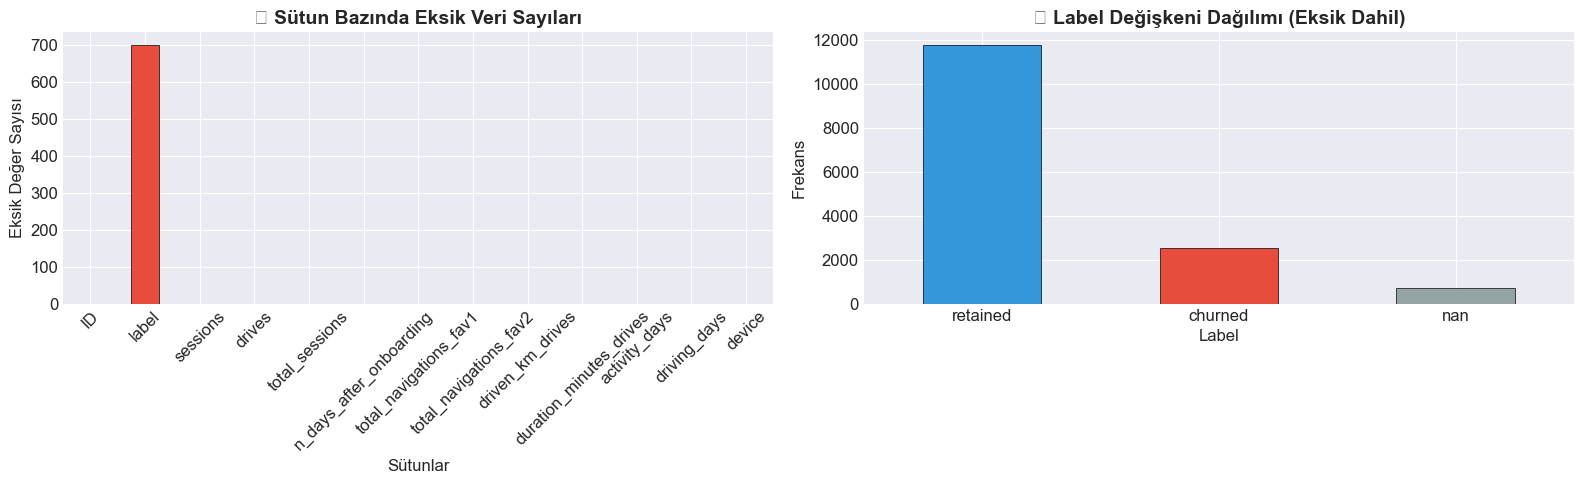

✅ Grafik outputs/eksik_veri_ve_label_dagilimi.png olarak kaydedildi.


In [39]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: Eksik veri sayıları
missing_counts = df.isnull().sum()
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in missing_counts]
missing_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('📊 Sütun Bazında Eksik Veri Sayıları', fontweight='bold')
axes[0].set_ylabel('Eksik Değer Sayısı')
axes[0].set_xlabel('Sütunlar')
axes[0].tick_params(axis='x', rotation=45)

# Sağ: Label dağılımı (eksik dahil)
label_counts = df['label'].value_counts(dropna=False)
label_counts.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='black', linewidth=0.5)
axes[1].set_title('📊 Label Değişkeni Dağılımı (Eksik Dahil)', fontweight='bold')
axes[1].set_ylabel('Frekans')
axes[1].set_xlabel('Label')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/eksik_veri_ve_label_dagilimi.png", bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Grafik {output_dir}/eksik_veri_ve_label_dagilimi.png olarak kaydedildi.")

## 2.4 Aykırı Değer Analizi

In [40]:
# Sayısal sütunları belirle
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'ID']

outlier_info = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_info.append({
        'Değişken': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Alt Sınır': round(lower_bound, 2),
        'Üst Sınır': round(upper_bound, 2),
        'Aykırı Değer Sayısı': len(outliers),
        'Aykırı Değer Oranı (%)': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_info)
outlier_df.to_csv(f"{output_dir}/aykiri_deger_analizi.csv", index=False)
print(f"✅ Aykırı değer analizi {output_dir}/aykiri_deger_analizi.csv olarak kaydedildi.")
outlier_df

✅ Aykırı değer analizi outputs/aykiri_deger_analizi.csv olarak kaydedildi.


,Değişken,Q1,Q3,IQR,Alt Sınır,Üst Sınır,Aykırı Değer Sayısı,Aykırı Değer Oranı (%)
0,sessions,23.00,112.00,89.00,-110.50,245.50,729,4.86
1,drives,20.00,93.00,73.00,-89.50,202.50,734,4.89
2,total_sessions,90.66,254.19,163.53,-154.64,499.49,515,3.43
3,n_days_after_onboarding,878.00,2623.50,1745.50,-1740.25,5241.75,0,0.00
4,total_navigations_fav1,9.00,178.00,169.00,-244.50,431.50,713,4.75
5,total_navigations_fav2,0.00,43.00,43.00,-64.50,107.50,1027,6.85
6,driven_km_drives,2212.60,5289.86,3077.26,-2403.29,9905.75,463,3.09
7,duration_minutes_drives,836.00,2464.36,1628.37,-1606.55,4906.91,644,4.29
8,activity_days,8.00,23.00,15.00,-14.50,45.50,0,0.00
9,driving_days,5.00,19.00,14.00,-16.00,40.00,0,0.00


## 2.5 İstatistiksel Özetler

In [41]:
# Tanımlayıcı istatistikler
stats_df = df.describe().T.round(2)
stats_df.to_csv(f"{output_dir}/sayisal_istatistikler.csv")
print(f"✅ Sayısal istatistikler {output_dir}/sayisal_istatistikler.csv olarak kaydedildi.")
stats_df

✅ Sayısal istatistikler outputs/sayisal_istatistikler.csv olarak kaydedildi.


,count,mean,std,min,25%,50%,75%,max
ID,14999.0,7499.00,4329.98,0.00,3749.50,7499.00,11248.50,14998.00
sessions,14999.0,80.63,80.70,0.00,23.00,56.00,112.00,743.00
drives,14999.0,67.28,65.91,0.00,20.00,48.00,93.00,596.00
total_sessions,14999.0,189.96,136.41,0.22,90.66,159.57,254.19,1216.15
n_days_after_onboarding,14999.0,1749.84,1008.51,4.00,878.00,1741.00,2623.50,3500.00
total_navigations_fav1,14999.0,121.61,148.12,0.00,9.00,71.00,178.00,1236.00
total_navigations_fav2,14999.0,29.67,45.39,0.00,0.00,9.00,43.00,415.00
driven_km_drives,14999.0,4039.34,2502.15,60.44,2212.60,3493.86,5289.86,21183.40
duration_minutes_drives,14999.0,1860.98,1446.70,18.28,836.00,1478.25,2464.36,15851.73
activity_days,14999.0,15.54,9.00,0.00,8.00,16.00,23.00,31.00


## 2.6 Görselleştirmeler

Tüm grafikler `outputs/` klasörüne otomatik olarak PNG formatında kaydedilmektedir.

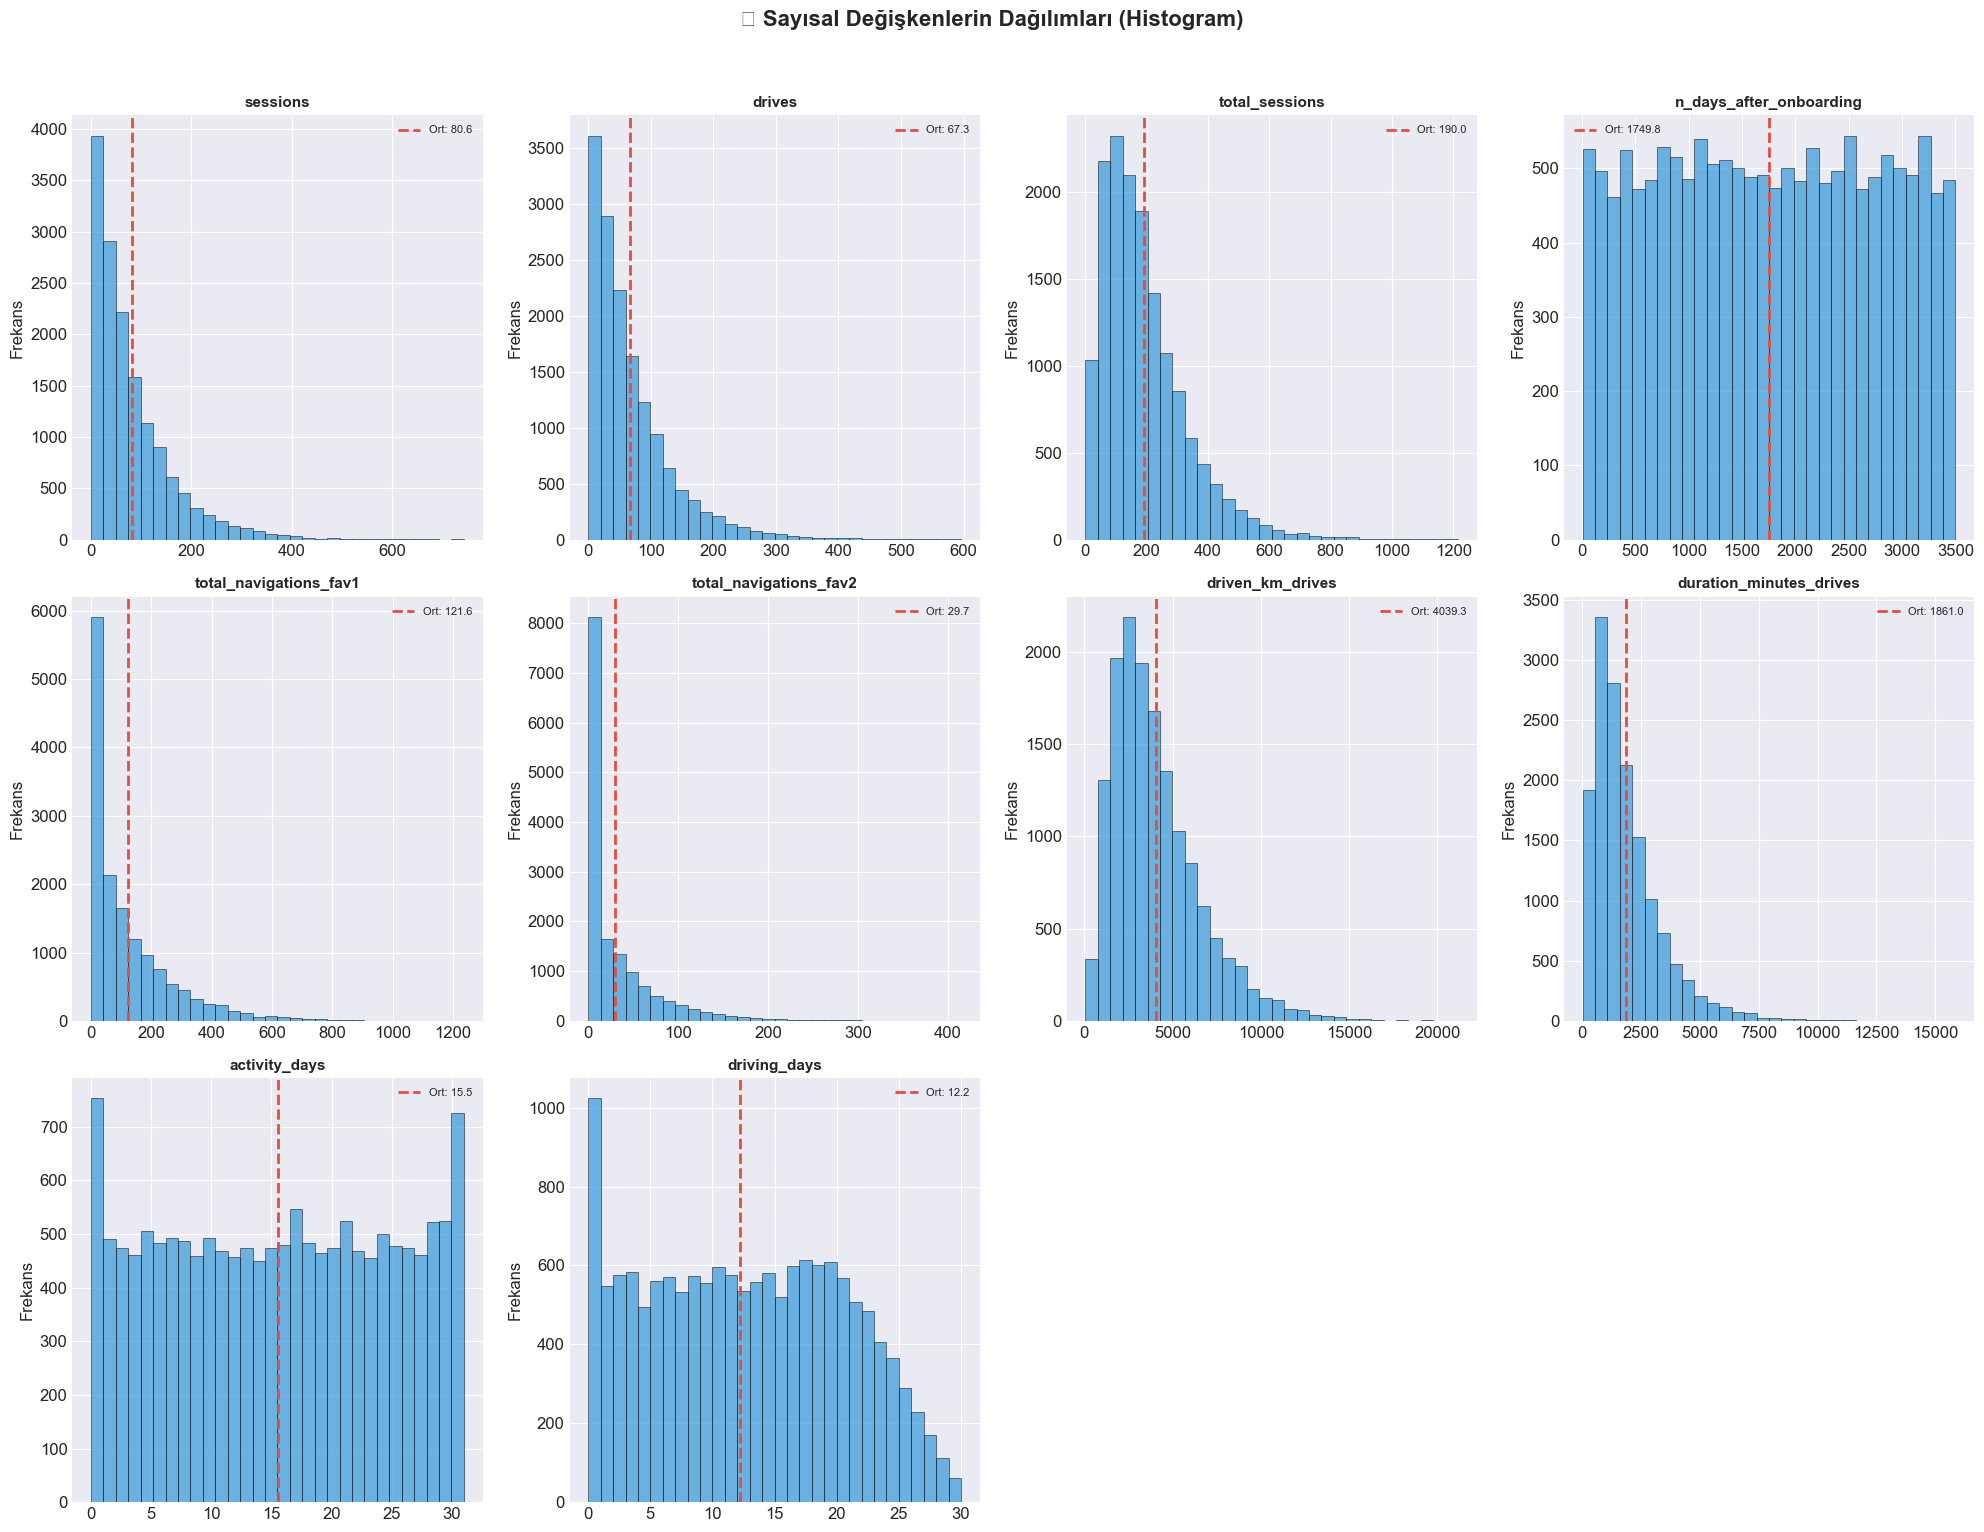

✅ Grafik outputs/histogram_dagilimlar.png olarak kaydedildi.


In [42]:
# Histogram - Tüm sayısal değişkenler
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='black',
                 alpha=0.7, linewidth=0.5)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekans')
    axes[i].axvline(df[col].mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Ort: {df[col].mean():.1f}')
    axes[i].legend(fontsize=8)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('📊 Sayısal Değişkenlerin Dağılımları (Histogram)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/histogram_dagilimlar.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/histogram_dagilimlar.png olarak kaydedildi.")

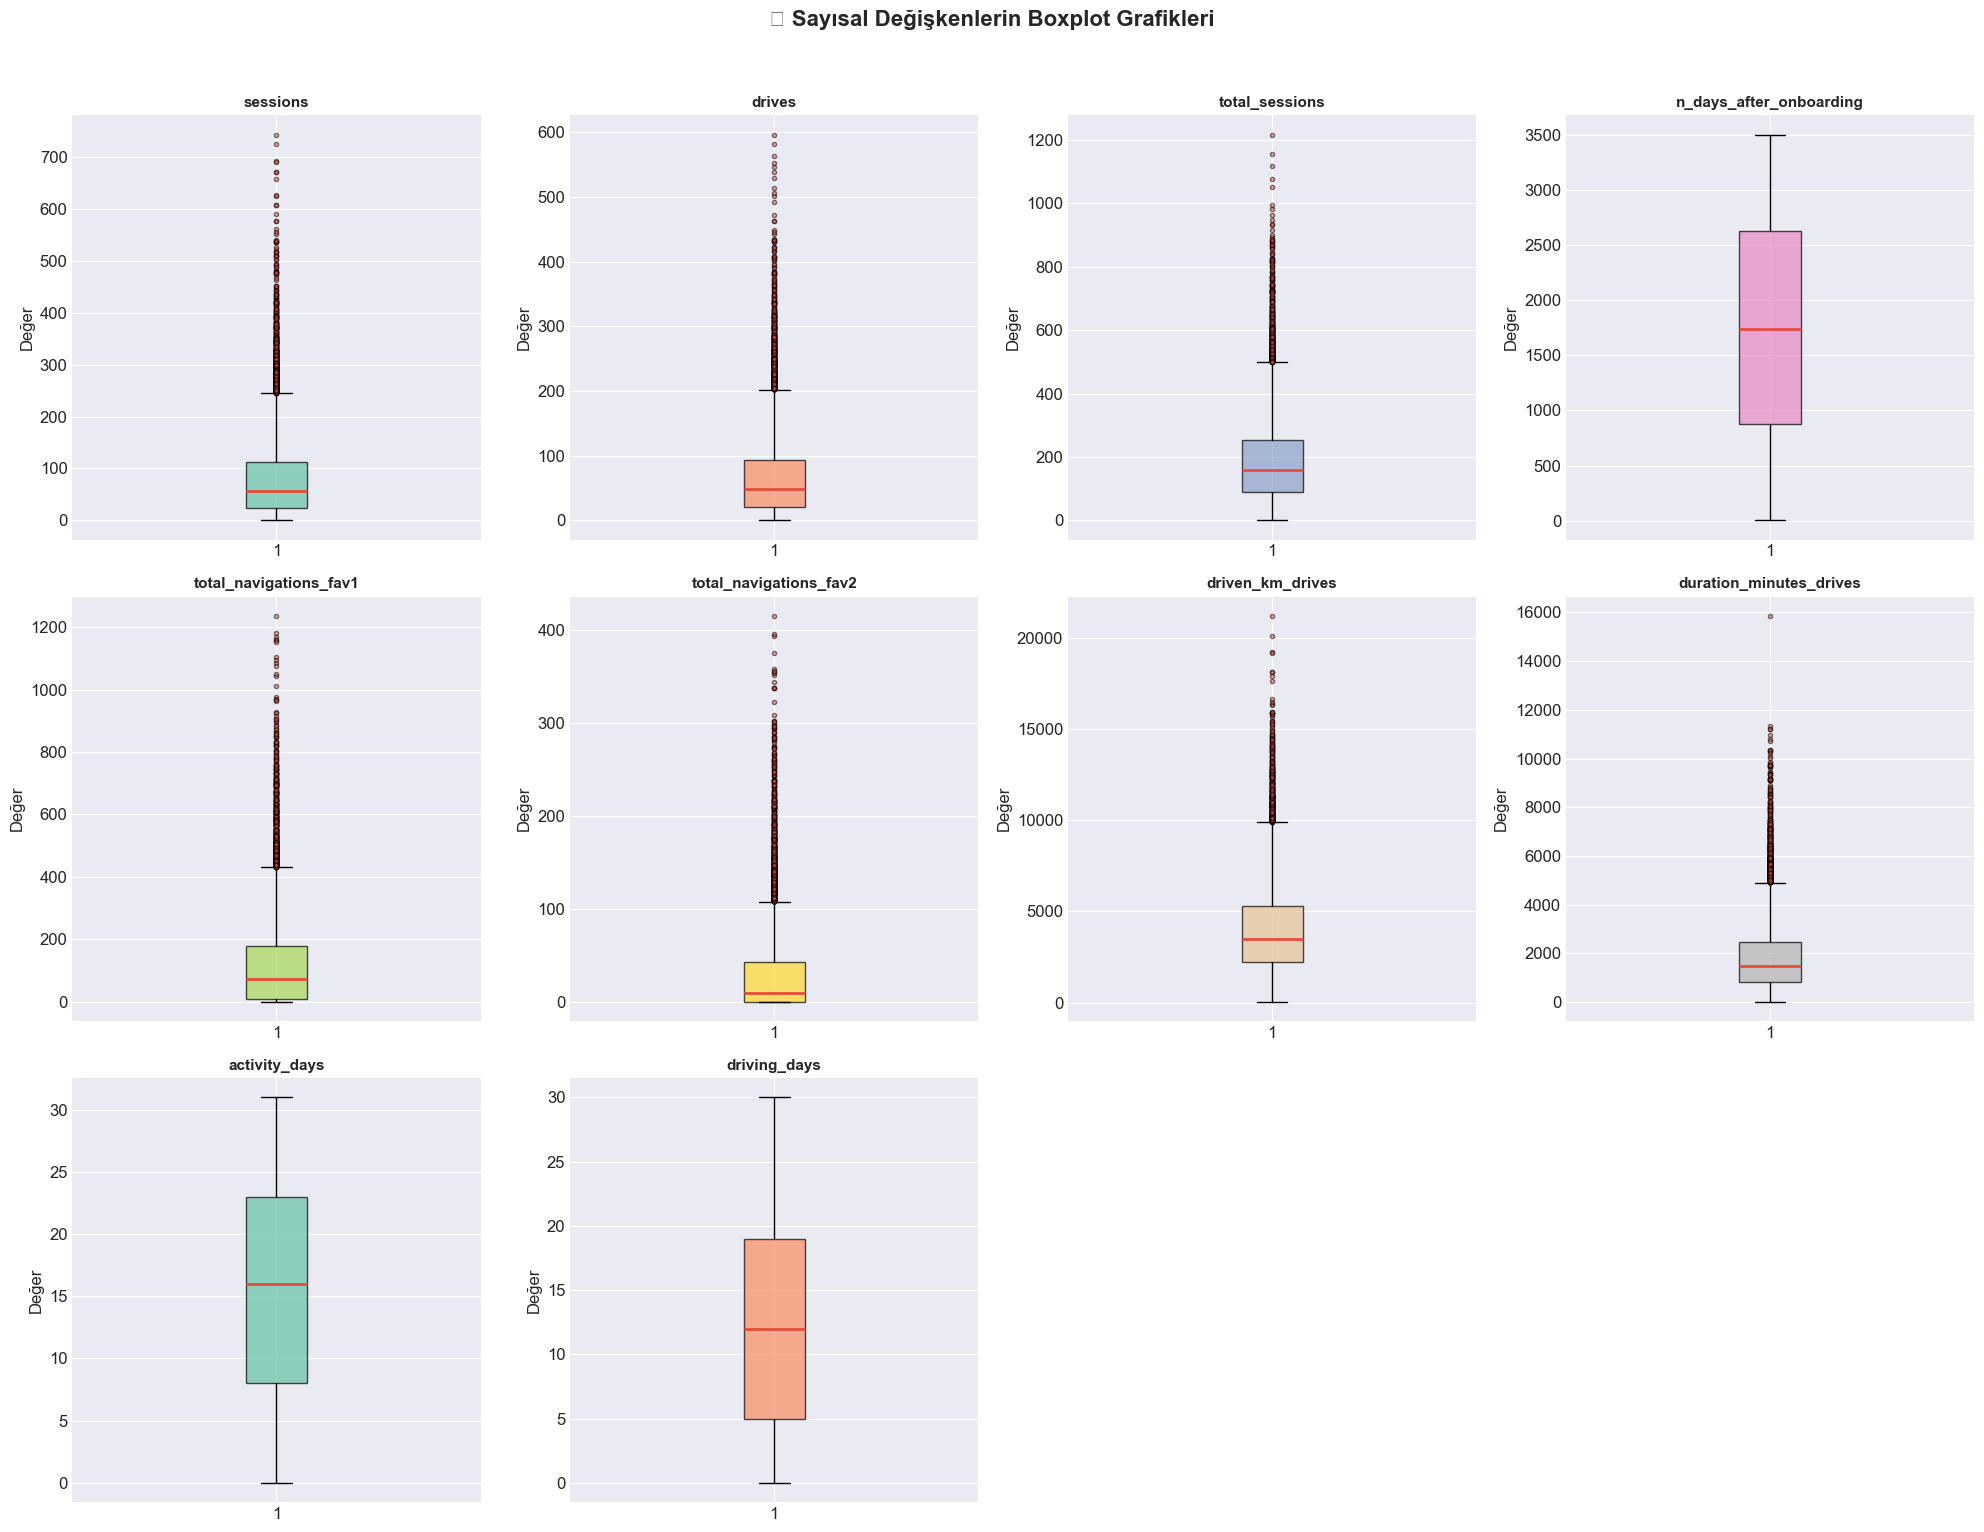

✅ Grafik outputs/boxplot_aykiri_degerler.png olarak kaydedildi.


In [43]:
# Boxplot - Aykırı değerleri görselleştir
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
colors = sns.color_palette('Set2', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, vert=True,
                         boxprops=dict(facecolor=colors[i], alpha=0.7),
                         medianprops=dict(color='#e74c3c', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.5))
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Değer')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('📊 Sayısal Değişkenlerin Boxplot Grafikleri', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/boxplot_aykiri_degerler.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/boxplot_aykiri_degerler.png olarak kaydedildi.")

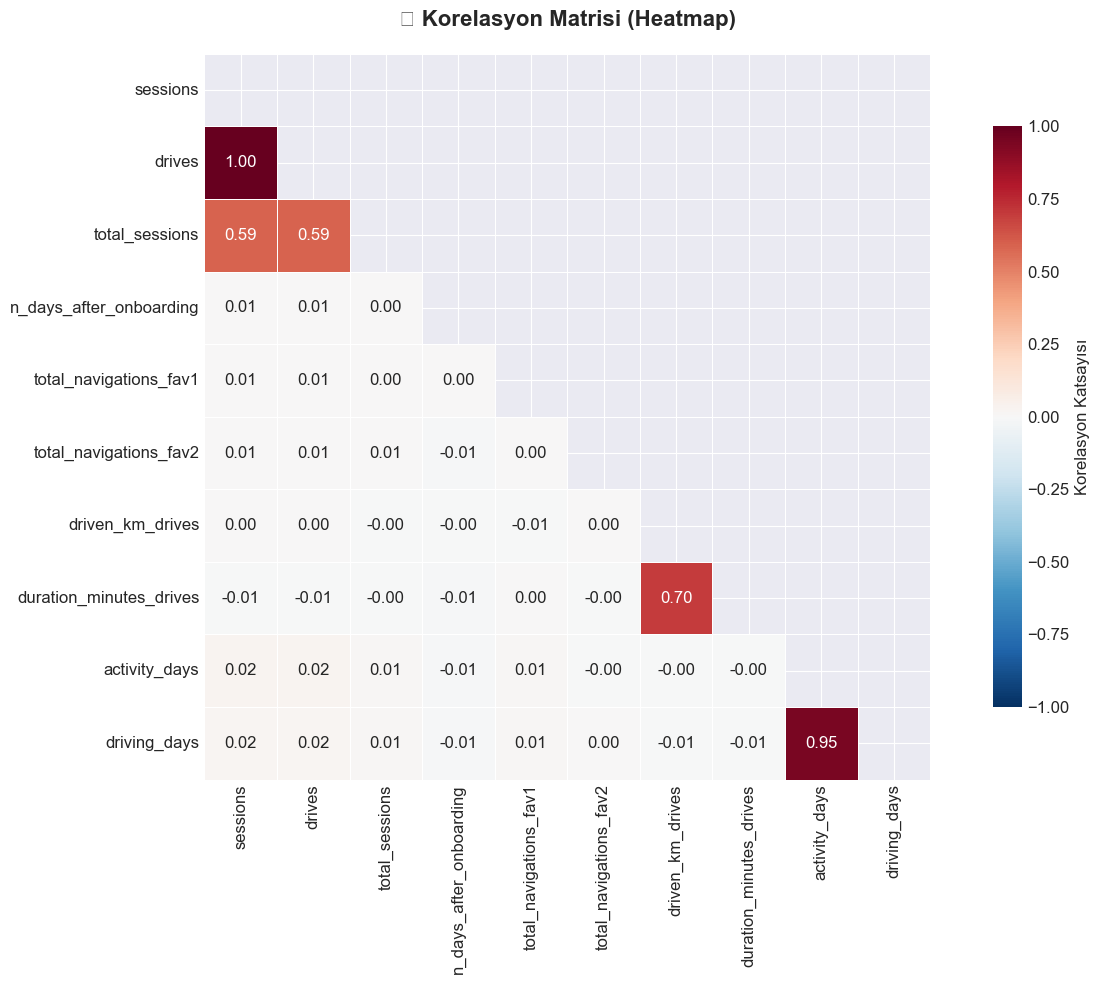

✅ Grafik outputs/korelasyon_heatmap.png olarak kaydedildi.


In [44]:
# Korelasyon matrisi
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Korelasyon Katsayısı'},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('📊 Korelasyon Matrisi (Heatmap)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{output_dir}/korelasyon_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/korelasyon_heatmap.png olarak kaydedildi.")

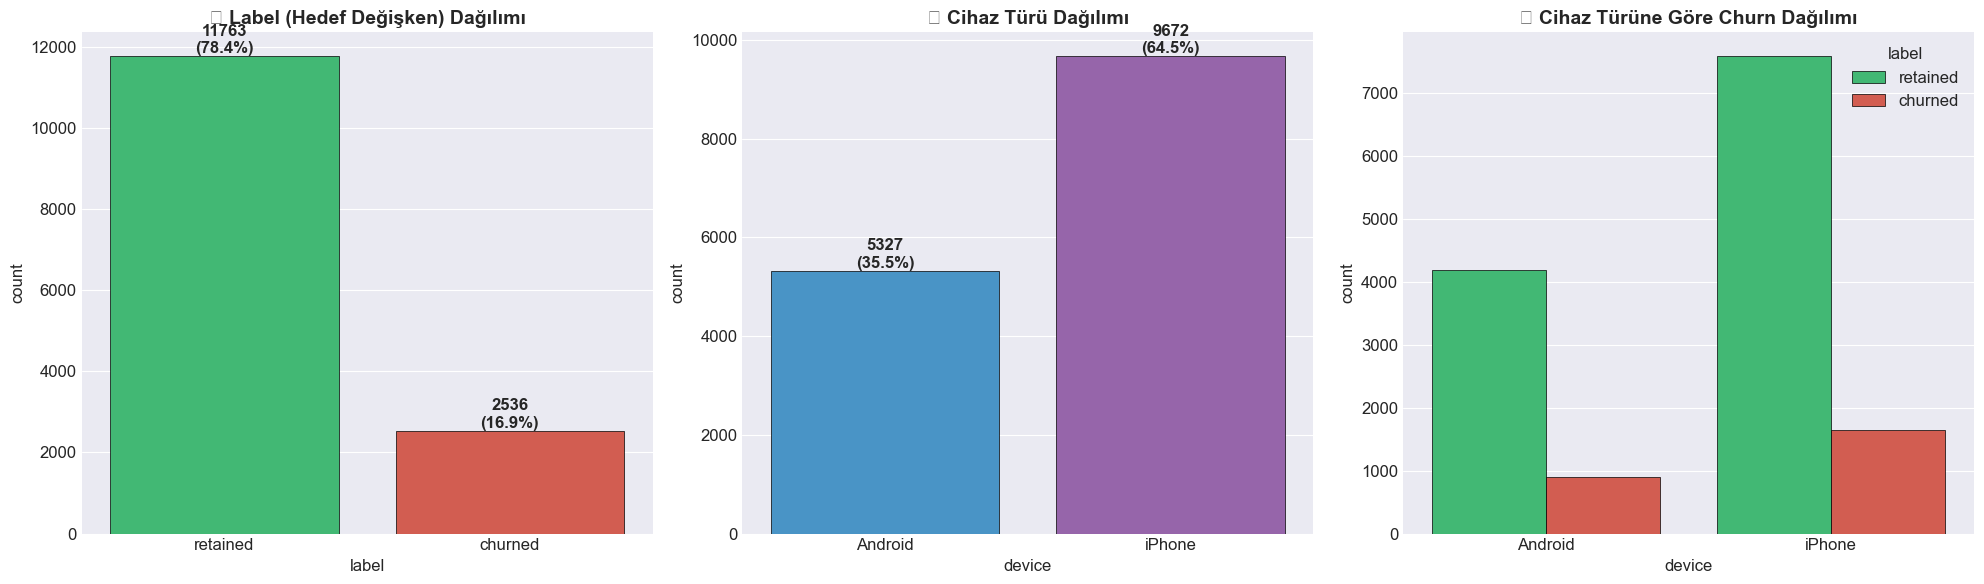

✅ Grafik outputs/kategorik_degiskenler_countplot.png olarak kaydedildi.


In [45]:
# Countplot - Label ve Device dağılımları
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

label_order = ['retained', 'churned']
ax1 = sns.countplot(data=df, x='label', order=label_order, ax=axes[0],
                     palette=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('📊 Label (Hedef Değişken) Dağılımı', fontweight='bold')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                 (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontweight='bold')

ax2 = sns.countplot(data=df, x='device', ax=axes[1],
                     palette=['#3498db', '#9b59b6'], edgecolor='black', linewidth=0.5)
axes[1].set_title('📊 Cihaz Türü Dağılımı', fontweight='bold')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                 (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontweight='bold')

ax3 = sns.countplot(data=df.dropna(subset=['label']), x='device', hue='label',
                     hue_order=label_order, ax=axes[2],
                     palette=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[2].set_title('📊 Cihaz Türüne Göre Churn Dağılımı', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{output_dir}/kategorik_degiskenler_countplot.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/kategorik_degiskenler_countplot.png olarak kaydedildi.")

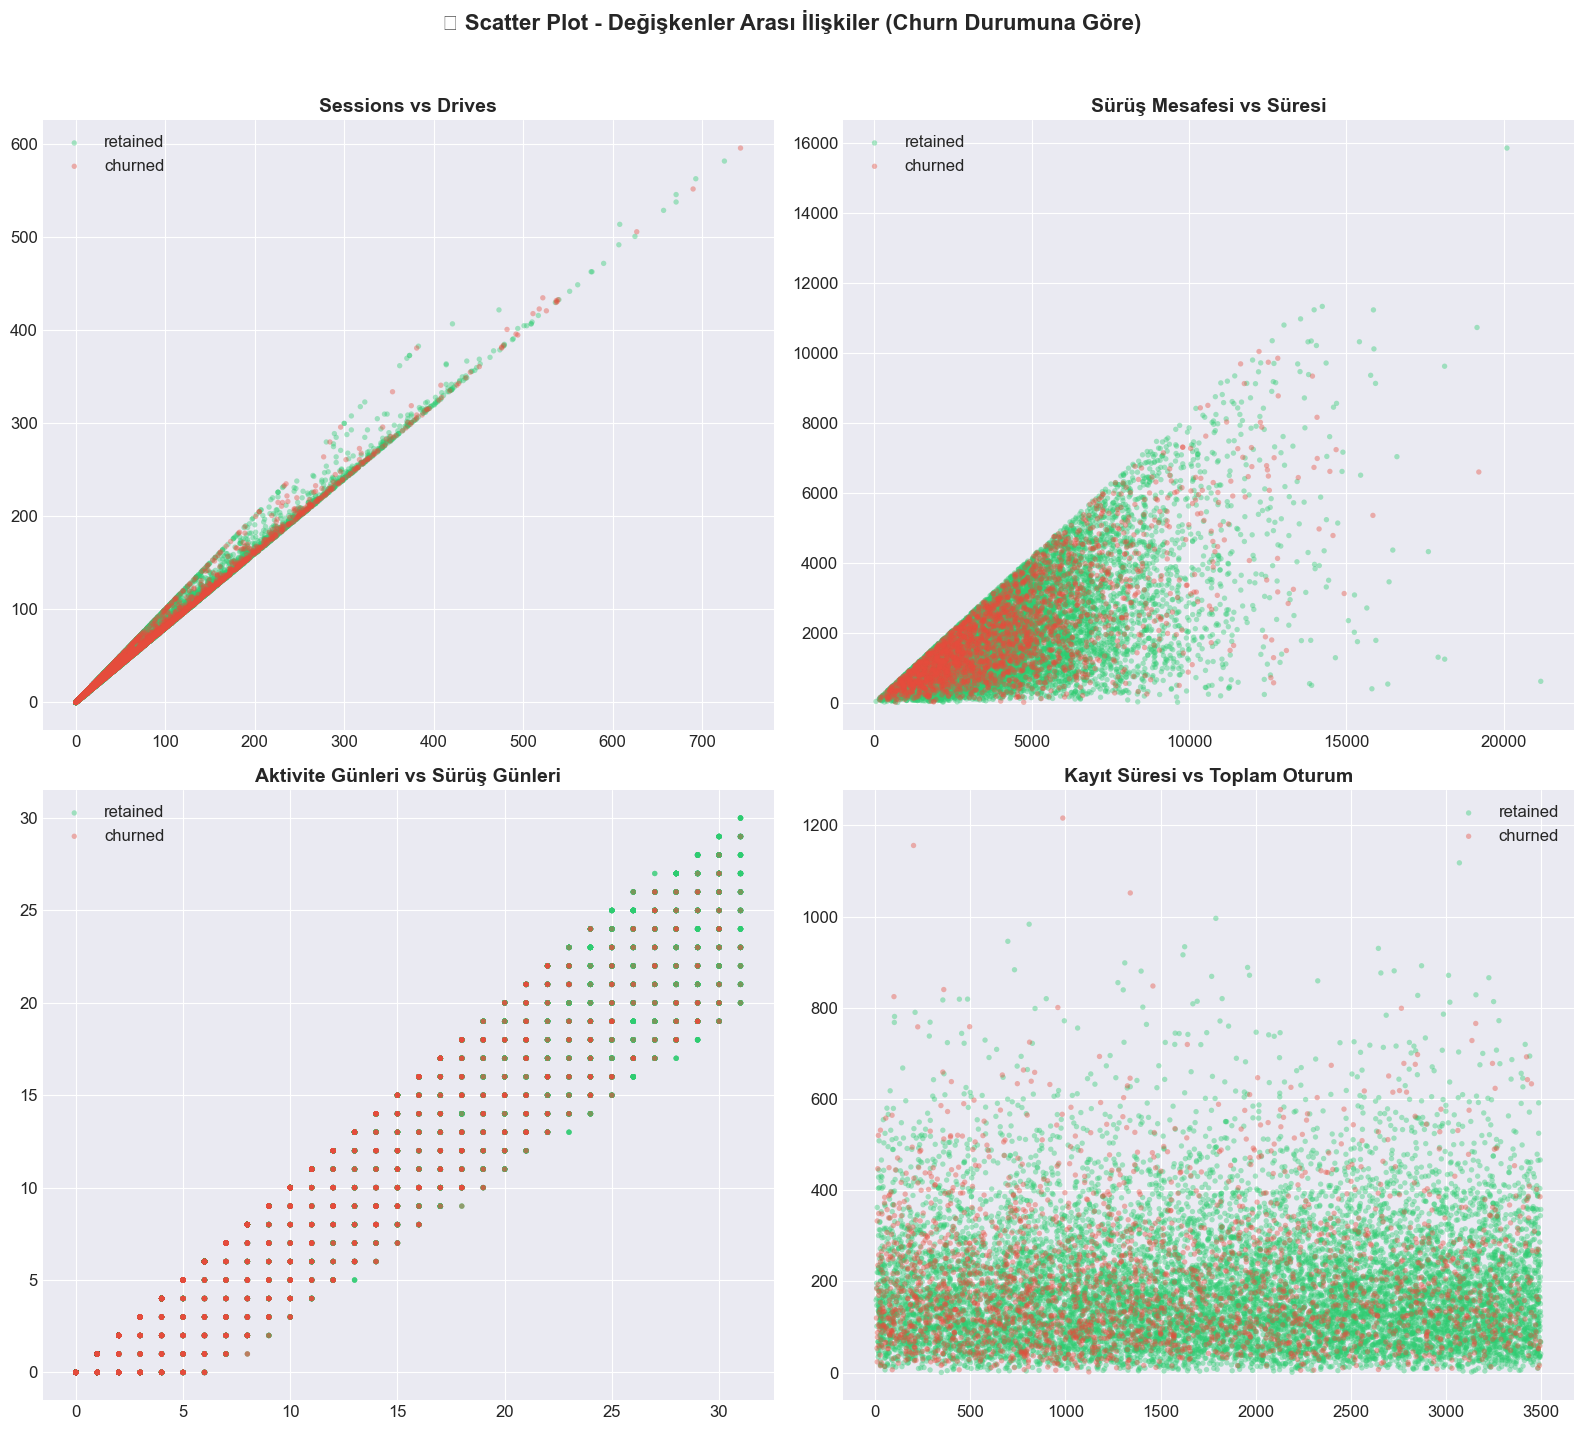

✅ Grafik outputs/scatter_plot_iliskiler.png olarak kaydedildi.


In [46]:
# Scatter Plot - Önemli değişken çiftleri
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
df_plot = df.dropna(subset=['label']).copy()
colors_map = {'retained': '#2ecc71', 'churned': '#e74c3c'}

for label_val, color in colors_map.items():
    subset = df_plot[df_plot['label'] == label_val]
    axes[0, 0].scatter(subset['sessions'], subset['drives'], c=color, label=label_val, alpha=0.4, s=15, edgecolors='none')
    axes[0, 1].scatter(subset['driven_km_drives'], subset['duration_minutes_drives'], c=color, label=label_val, alpha=0.4, s=15, edgecolors='none')
    axes[1, 0].scatter(subset['activity_days'], subset['driving_days'], c=color, label=label_val, alpha=0.4, s=15, edgecolors='none')
    axes[1, 1].scatter(subset['n_days_after_onboarding'], subset['total_sessions'], c=color, label=label_val, alpha=0.4, s=15, edgecolors='none')

axes[0, 0].set_title('Sessions vs Drives', fontweight='bold'); axes[0, 0].legend()
axes[0, 1].set_title('Sürüş Mesafesi vs Süresi', fontweight='bold'); axes[0, 1].legend()
axes[1, 0].set_title('Aktivite Günleri vs Sürüş Günleri', fontweight='bold'); axes[1, 0].legend()
axes[1, 1].set_title('Kayıt Süresi vs Toplam Oturum', fontweight='bold'); axes[1, 1].legend()

fig.suptitle('📊 Scatter Plot - Değişkenler Arası İlişkiler (Churn Durumuna Göre)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/scatter_plot_iliskiler.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/scatter_plot_iliskiler.png olarak kaydedildi.")

---
# 3. Veri Ön İşleme


In [47]:
df_clean = df.dropna(subset=['label']).copy()
df_clean['label_encoded'] = (df_clean['label'] == 'churned').astype(int)
df_clean['device_encoded'] = (df_clean['device'] == 'iPhone').astype(int)

df_clean['drives_per_session'] = (df_clean['drives'] / df_clean['sessions'].replace(0, np.nan)).fillna(0)
df_clean['km_per_driving_day'] = (df_clean['driven_km_drives'] / df_clean['driving_days'].replace(0, np.nan)).fillna(0)
df_clean['minutes_per_drive'] = (df_clean['duration_minutes_drives'] / df_clean['drives'].replace(0, np.nan)).fillna(0)
df_clean['activity_driving_ratio'] = (df_clean['driving_days'] / df_clean['activity_days'].replace(0, np.nan)).fillna(0)
df_clean['total_fav_navigations'] = df_clean['total_navigations_fav1'] + df_clean['total_navigations_fav2']
df_clean['km_per_drive'] = (df_clean['driven_km_drives'] / df_clean['drives'].replace(0, np.nan)).fillna(0)

drop_cols = ['ID', 'label', 'device', 'label_encoded']
feature_cols = [col for col in df_clean.columns if col not in drop_cols]

X = df_clean[feature_cols].copy()
y = df_clean['label_encoded'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Veri ön işleme adımları (Temizleme, Encoding, Feature Engineering, Scaling) tamamlandı.")

✅ Veri ön işleme adımları (Temizleme, Encoding, Feature Engineering, Scaling) tamamlandı.


---
# 4. Modelleme


In [48]:
# Logistic Regression Eğitimi
lr_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({'Özellik': feature_cols, 'Katsayı': lr_model.coef_[0]}).sort_values('Katsayı', key=abs, ascending=False)
coef_df.to_csv(f"{output_dir}/lr_model_katsayilari.csv", index=False)
print(f"✅ Logistic Regression katsayıları {output_dir}/lr_model_katsayilari.csv olarak kaydedildi.")

lr_y_pred = lr_model.predict(X_test_scaled)
lr_y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

✅ Logistic Regression katsayıları outputs/lr_model_katsayilari.csv olarak kaydedildi.


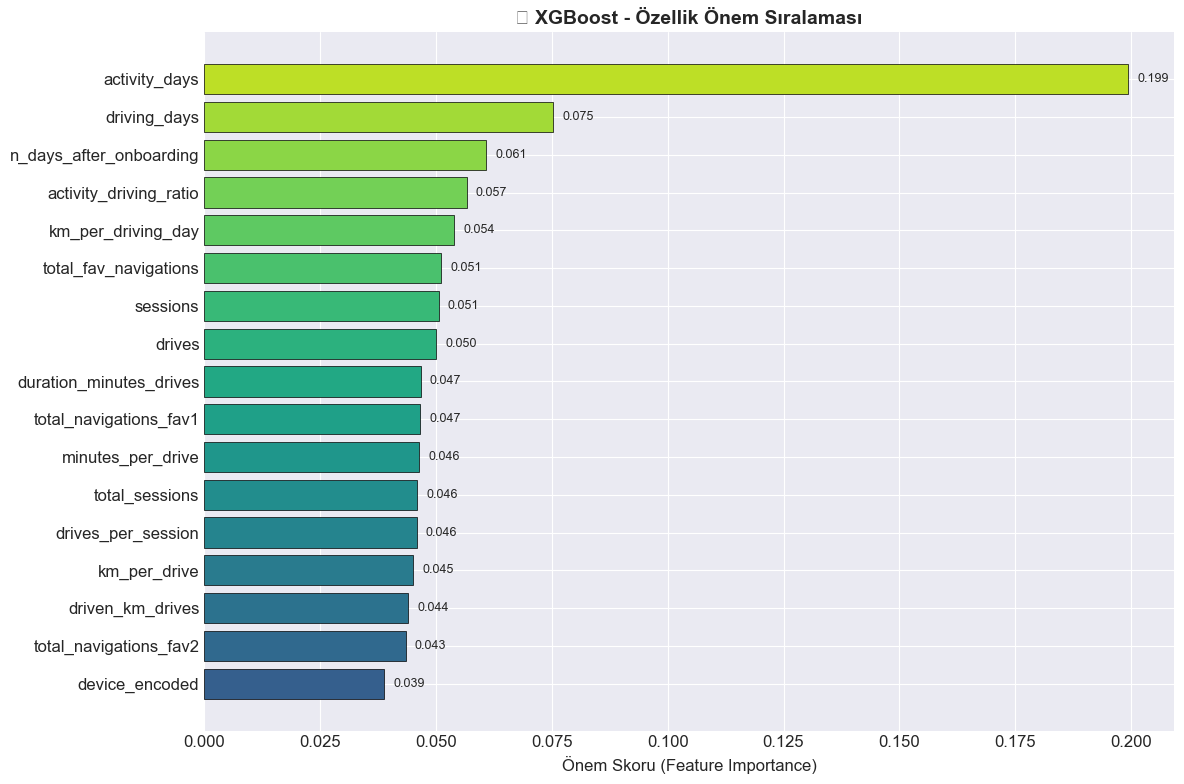

✅ XGBoost Özellik Önemleri outputs/xgboost_feature_importance.png ve .csv olarak kaydedildi.


In [49]:
# XGBoost Eğitimi
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                          min_child_weight=5, gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
                          scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X_train_scaled, y_train)

xgb_y_pred = xgb_model.predict(X_test_scaled)
xgb_y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost Feature Importance Plot
fig, ax = plt.subplots(figsize=(12, 8))
importance_df = pd.DataFrame({'Özellik': feature_cols, 'Önem Skoru': xgb_model.feature_importances_}).sort_values('Önem Skoru', ascending=True)
importance_df.to_csv(f"{output_dir}/xgboost_feature_importance.csv", index=False)

bars = ax.barh(importance_df['Özellik'], importance_df['Önem Skoru'], color=plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df))), edgecolor='black', linewidth=0.5)
ax.set_xlabel('Önem Skoru (Feature Importance)')
ax.set_title('📊 XGBoost - Özellik Önem Sıralaması', fontweight='bold')
for bar, val in zip(bars, importance_df['Önem Skoru']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{output_dir}/xgboost_feature_importance.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ XGBoost Özellik Önemleri {output_dir}/xgboost_feature_importance.png ve .csv olarak kaydedildi.")

---
# 5. Model Değerlendirme


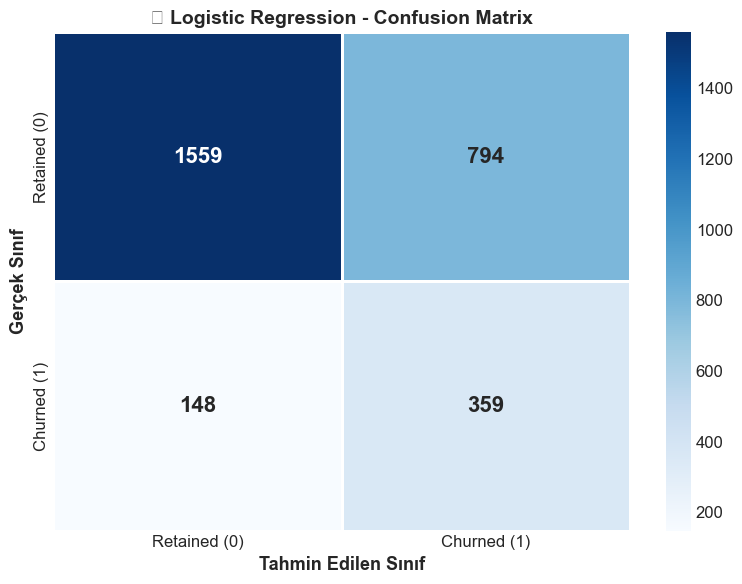

✅ Grafik outputs/lr_confusion_matrix.png olarak kaydedildi.


In [50]:
# Logistic Regression CM Plot
fig, ax = plt.subplots(figsize=(8, 6))
lr_cm = confusion_matrix(y_test, lr_y_pred)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Retained (0)', 'Churned (1)'], yticklabels=['Retained (0)', 'Churned (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'}, linewidths=2, linecolor='white', ax=ax)
ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=13, fontweight='bold')
ax.set_ylabel('Gerçek Sınıf', fontsize=13, fontweight='bold')
ax.set_title('📊 Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_dir}/lr_confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/lr_confusion_matrix.png olarak kaydedildi.")

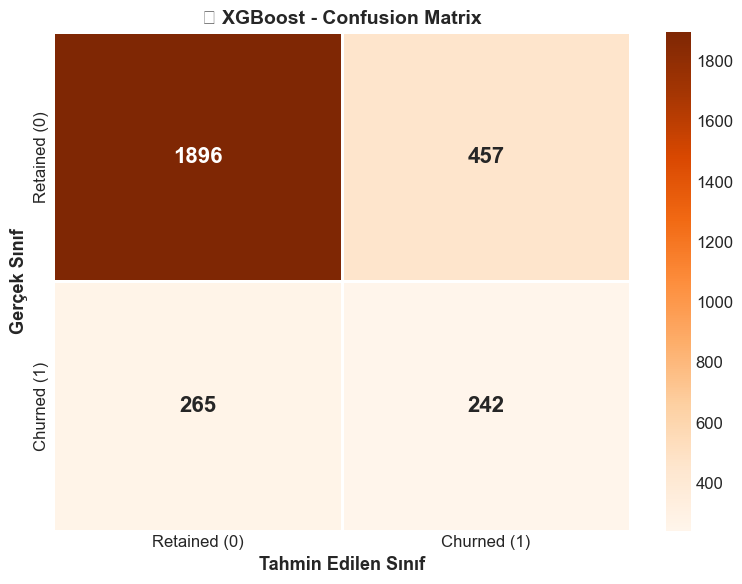

✅ Grafik outputs/xgb_confusion_matrix.png olarak kaydedildi.


In [51]:
# XGBoost CM Plot
fig, ax = plt.subplots(figsize=(8, 6))
xgb_cm = confusion_matrix(y_test, xgb_y_pred)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['Retained (0)', 'Churned (1)'], yticklabels=['Retained (0)', 'Churned (1)'],
            annot_kws={'size': 16, 'fontweight': 'bold'}, linewidths=2, linecolor='white', ax=ax)
ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=13, fontweight='bold')
ax.set_ylabel('Gerçek Sınıf', fontsize=13, fontweight='bold')
ax.set_title('📊 XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_dir}/xgb_confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/xgb_confusion_matrix.png olarak kaydedildi.")

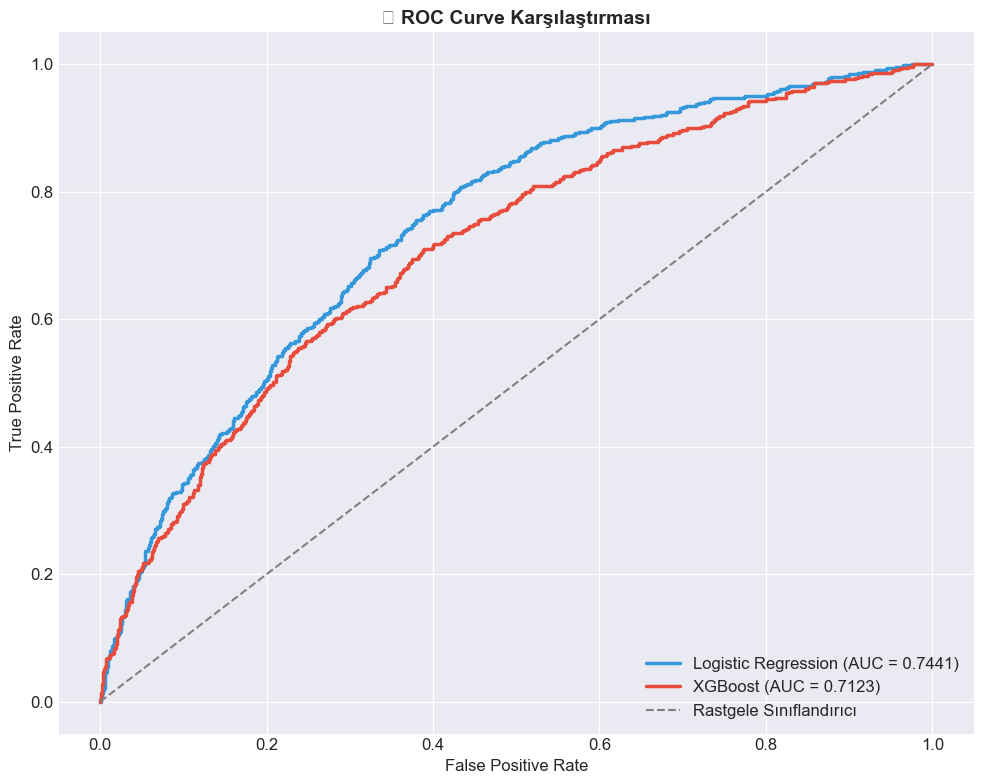

✅ Grafik outputs/roc_curve_karsilastirmasi.png olarak kaydedildi.


In [52]:
# ROC Curve - Her iki model
lr_roc_auc = roc_auc_score(y_test, lr_y_prob)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_prob)

fig, ax = plt.subplots(figsize=(10, 8))
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_y_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_y_prob)
ax.plot(lr_fpr, lr_tpr, color='#3498db', linewidth=2.5, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')
ax.plot(xgb_fpr, xgb_tpr, color='#e74c3c', linewidth=2.5, label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Rastgele Sınıflandırıcı')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('📊 ROC Curve Karşılaştırması', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curve_karsilastirmasi.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/roc_curve_karsilastirmasi.png olarak kaydedildi.")

---
# 6. Model Karşılaştırması

In [53]:
lr_accuracy, lr_precision, lr_recall, lr_f1 = accuracy_score(y_test, lr_y_pred), precision_score(y_test, lr_y_pred), recall_score(y_test, lr_y_pred), f1_score(y_test, lr_y_pred)
xgb_accuracy, xgb_precision, xgb_recall, xgb_f1 = accuracy_score(y_test, xgb_y_pred), precision_score(y_test, xgb_y_pred), recall_score(y_test, xgb_y_pred), f1_score(y_test, xgb_y_pred)

comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc],
    'XGBoost': [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc]
}).round(4)

comparison_df.to_csv(f"{output_dir}/model_karsilastirma_tablosu.csv", index=False)
print(f"✅ Karşılaştırma tablosu {output_dir}/model_karsilastirma_tablosu.csv olarak kaydedildi.")
comparison_df

✅ Karşılaştırma tablosu outputs/model_karsilastirma_tablosu.csv olarak kaydedildi.


,Metrik,Logistic Regression,XGBoost
0,Accuracy,0.6706,0.7476
1,Precision,0.3114,0.3462
2,Recall,0.7081,0.4773
3,F1-Score,0.4325,0.4013
4,ROC-AUC,0.7441,0.7123


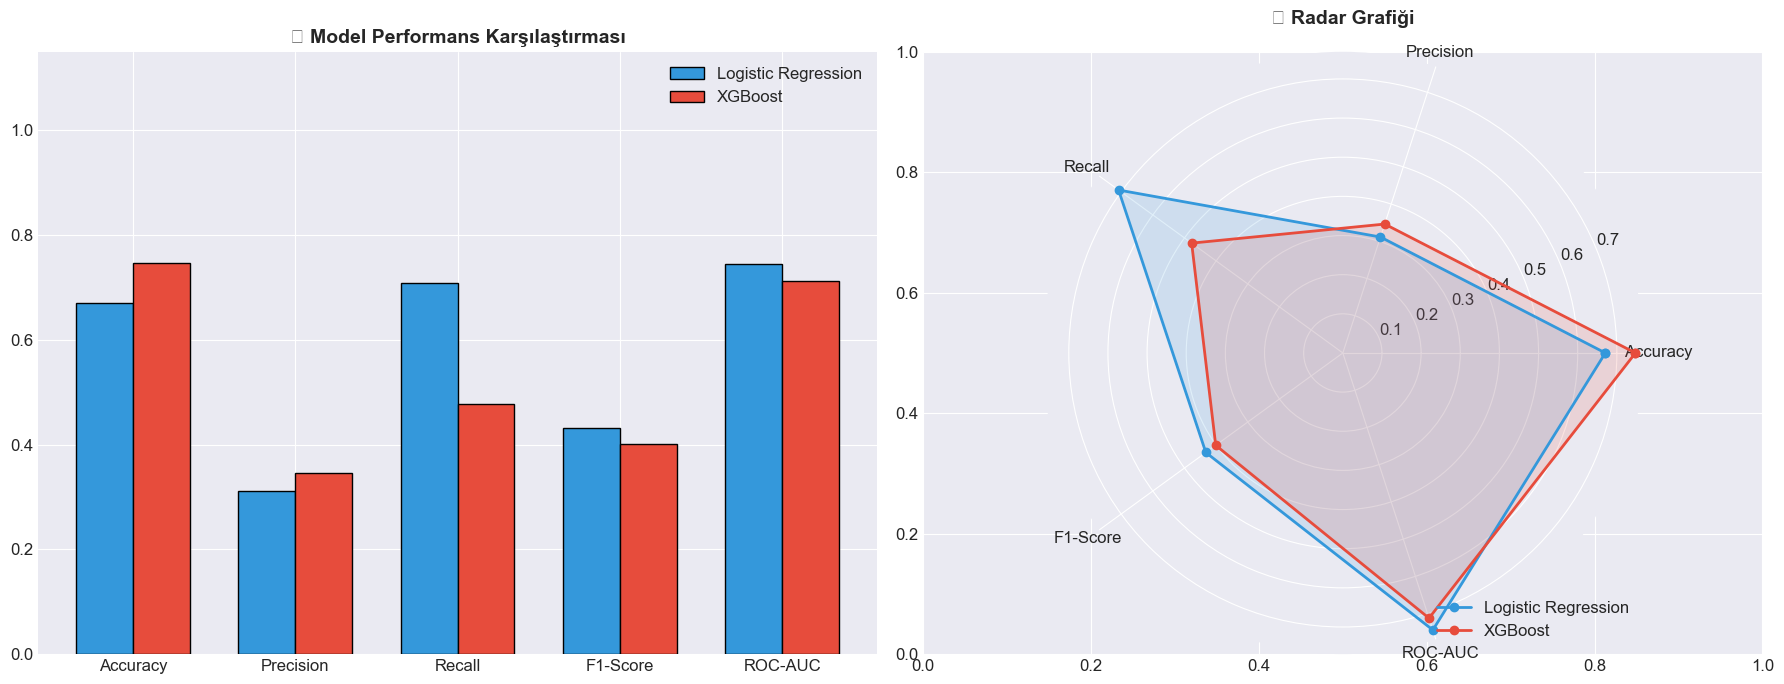

✅ Grafik outputs/model_performans_karsilastirma.png olarak kaydedildi.


In [54]:
# Karşılaştırma Görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc]
xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc]

x = np.arange(len(metrics))
width = 0.35
bars1 = axes[0].bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, xgb_scores, width, label='XGBoost', color='#e74c3c', edgecolor='black')
axes[0].set_title('📊 Model Performans Karşılaştırması', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].legend(); axes[0].set_ylim(0, 1.15)

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
lr_scores_radar = lr_scores + lr_scores[:1]
xgb_scores_radar = xgb_scores + xgb_scores[:1]

axes[1] = fig.add_subplot(122, projection='polar')
axes[1].plot(angles, lr_scores_radar, 'o-', linewidth=2, color='#3498db', label='Logistic Regression')
axes[1].fill(angles, lr_scores_radar, alpha=0.15, color='#3498db')
axes[1].plot(angles, xgb_scores_radar, 'o-', linewidth=2, color='#e74c3c', label='XGBoost')
axes[1].fill(angles, xgb_scores_radar, alpha=0.15, color='#e74c3c')
axes[1].set_xticks(angles[:-1]); axes[1].set_xticklabels(metrics)
axes[1].set_title('📊 Radar Grafiği', fontweight='bold', pad=20)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(f"{output_dir}/model_performans_karsilastirma.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Grafik {output_dir}/model_performans_karsilastirma.png olarak kaydedildi.")

---
## Tahmin Sonuçlarının CSV Olarak Kaydedilmesi

In [55]:
# Tahmin sonuçlarını outputs klasörüne CSV olarak kaydet
results_df = pd.DataFrame({
    'ID': df_clean.loc[X_test.index, 'ID'].values,
    'Gerçek_Label': y_test.values,
    'LR_Tahmin': lr_y_pred,
    'LR_Olasılık': lr_y_prob.round(4),
    'XGB_Tahmin': xgb_y_pred,
    'XGB_Olasılık': xgb_y_prob.round(4)
})

results_df['Gerçek_Label_Metin'] = results_df['Gerçek_Label'].map({0: 'retained', 1: 'churned'})
results_df['LR_Tahmin_Metin'] = results_df['LR_Tahmin'].map({0: 'retained', 1: 'churned'})
results_df['XGB_Tahmin_Metin'] = results_df['XGB_Tahmin'].map({0: 'retained', 1: 'churned'})

output_csv = f"{output_dir}/churn_prediction_results.csv"
results_df.to_csv(output_csv, index=False)

print(f"✅ Tahmin sonuçları '{output_csv}' dosyasına kaydedildi!")
results_df.head()

✅ Tahmin sonuçları 'outputs/churn_prediction_results.csv' dosyasına kaydedildi!


,ID,Gerçek_Label,LR_Tahmin,LR_Olasılık,XGB_Tahmin,XGB_Olasılık,Gerçek_Label_Metin,LR_Tahmin_Metin,XGB_Tahmin_Metin
0,11240,0,0,0.4002,0,0.3511,retained,retained,retained
1,13772,0,1,0.6259,1,0.6366,retained,churned,churned
2,2005,0,0,0.3406,0,0.2415,retained,retained,retained
3,10174,0,0,0.3758,0,0.1803,retained,retained,retained
4,12993,0,1,0.5286,0,0.4272,retained,churned,retained
